## Simple Linear Regression

In [30]:
# use when you have single perdictor which is continous and responce which is also continous 

In [31]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split

In [32]:
df = pd.read_excel('CDAC_DataBook.xlsx',sheet_name='faithful')

df


,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85
...,...,...
267,4.117,81
268,2.150,46
269,4.417,90
270,1.817,46


Text(0, 0.5, 'waiting')

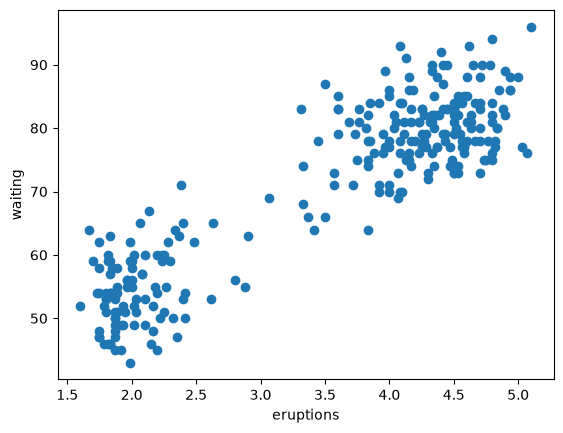

In [33]:
plt.scatter(df['eruptions'],df['waiting'])
plt.xlabel("eruptions")
plt.ylabel("waiting")

In [34]:
X = df.eruptions
y = df.waiting

In [35]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   eruptions  272 non-null    float64
 1   waiting    272 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 4.4 KB


In [37]:
X_train.head()

33     4.033
184    2.033
142    4.533
197    4.366
37     4.833
Name: eruptions, dtype: float64

In [38]:
X_train.info()

<class 'pandas.Series'>
Index: 217 entries, 33 to 102
Series name: eruptions
Non-Null Count  Dtype  
--------------  -----  
217 non-null    float64
dtypes: float64(1)
memory usage: 3.4 KB


In [39]:
y_train.head()

33     80
184    51
142    82
197    77
37     80
Name: waiting, dtype: int64

In [40]:
y_train.info()

<class 'pandas.Series'>
Index: 217 entries, 33 to 102
Series name: waiting
Non-Null Count  Dtype
--------------  -----
217 non-null    int64
dtypes: int64(1)
memory usage: 3.4 KB


In [41]:
from sklearn.linear_model import LinearRegression
m1=  LinearRegression()
X_train = np.array(X_train).reshape(-1,1)

m1.fit(X_train,y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[10.78]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,33.07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[17.29]


In [42]:
m1.coef_

array([10.78099868])

In [43]:
m1.intercept_

np.float64(33.07006162374168)

In [44]:
m1.score(X_train,y_train) #r_squr indicate the % of vairation explain by the model 

0.8262346542339201

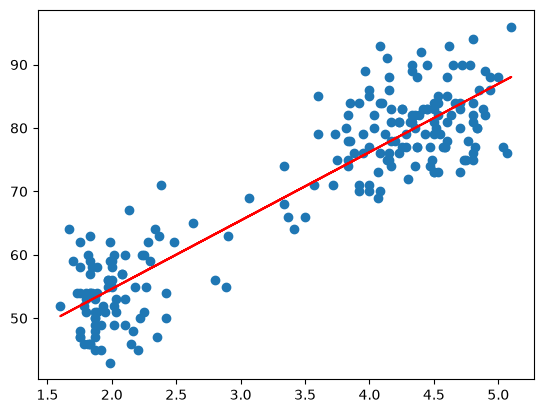

In [45]:
plt.scatter(X_train,y_train)
plt.plot(X_train,m1.predict(X_train),'r')

In [49]:

y_pred_test = m1.predict(np.array(X_test).reshape(-1,1))

In [50]:
y_pred_test

array([79.42835596, 58.04963557, 71.88165689, 81.5845557 , 70.80355702,
       86.25272813, 81.5845557 , 68.83063426, 52.47585925, 80.15068288,
       73.68208367, 80.68973281, 79.07258301, 77.27215623, 82.47937859,
       75.8275024 , 77.08887925, 83.01842853, 76.73310629, 57.14403168,
       79.07258301, 77.45543321, 74.39362958, 82.30688261, 80.86222879,
       79.9674059 , 70.26450708, 83.38498248, 72.77647978, 81.94032866,
       80.68973281, 55.3543859 , 79.78412892, 76.19405636, 71.52588393,
       83.74075544, 61.28393518, 83.74075544, 80.68973281, 52.65913623,
       71.88165689, 73.68208367, 82.47937859, 78.88930603, 82.30688261,
       58.94445846, 56.78825873, 53.90973208, 85.00213228, 53.37068215,
       56.43248577, 58.94445846, 78.16697912, 56.78825873, 83.01842853])

In [51]:
y_test

30     73
116    50
79     83
127    82
196    87
137    86
209    83
45     83
158    53
247    82
183    83
269    90
227    78
82     70
165    76
194    77
226    78
146    80
104    81
60     59
221    82
267    81
46     64
42     84
185    78
9      85
22     78
199    78
109    81
24     74
113    79
68     65
144    76
224    78
252    73
6      88
120    53
67     78
119    87
118    59
25     83
125    81
244    85
19     79
77     78
216    53
90     60
208    49
93     78
180    55
15     52
152    65
232    86
250    54
115    81
Name: waiting, dtype: int64

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [ ]:
## Read the dataset
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

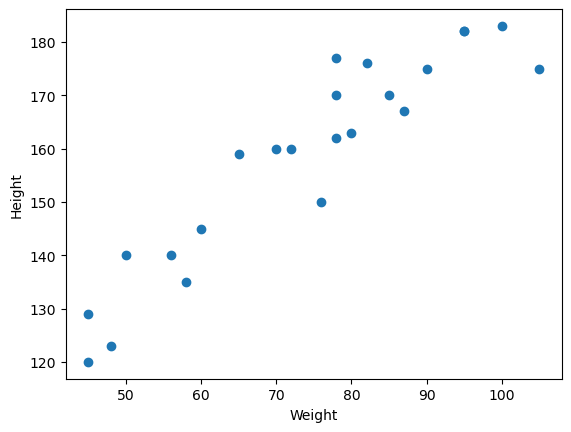

In [ ]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [ ]:
## divide our dataset into independent and dependent edatures
X=df[['Weight']] ##independent feature   :  input 
y=df['Height'] ##dependent feature  : output 

In [ ]:
## Train test split
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [ ]:
X.shape

(23, 1)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [ ]:
## standardize the dataset Train independent data
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
X_train.head()

,Weight
12,105
1,58
13,100
5,78
2,48


In [ ]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

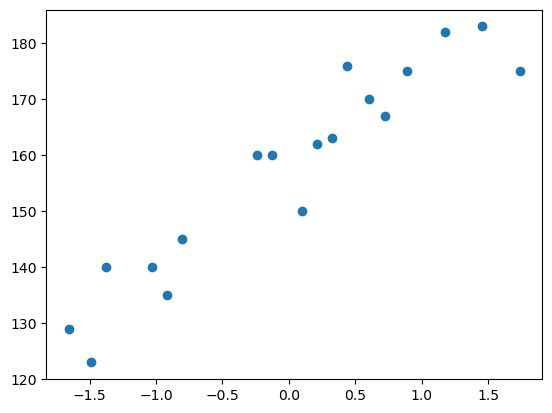

In [ ]:
plt.scatter(X_train,y_train)

In [ ]:
## Train the Simple Linear Regression Model
from sklearn.linear_model import LinearRegression

In [ ]:
regressor=LinearRegression()

In [ ]:
regressor.fit(X_train,y_train)

LinearRegression()

In [ ]:
print("The slope or coefficient of weight is ",regressor.coef_)
print("Intercept:",regressor.intercept_)

The slope or coefficient of weight is  [17.03440872]
Intercept: 157.5


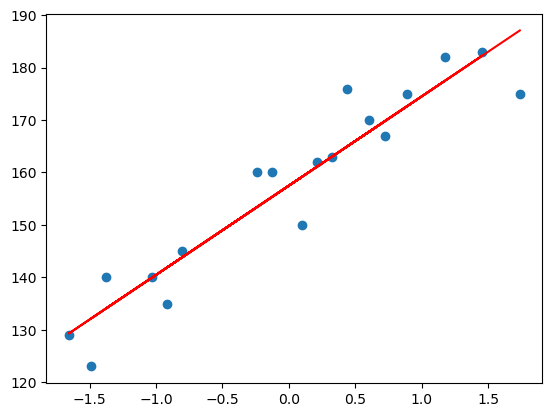

In [ ]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),'r')

### prediction of train data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_train =157.5 + 17.03(X_train)
          
### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =157.5 + 17.03(X_test)

In [ ]:
y_pred_test=regressor.predict(X_test)

In [ ]:
y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

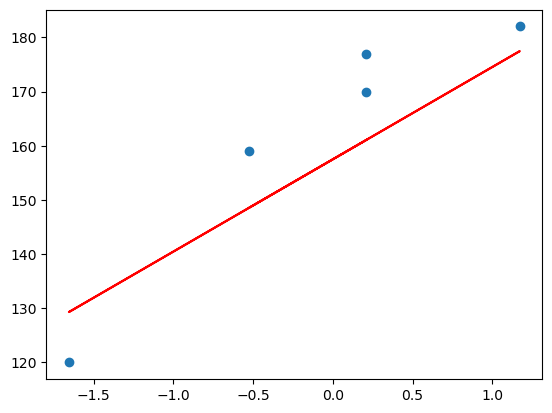

In [ ]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regressor.predict(X_test),'r')

## Performance Metrics

## MSE,MAE,RMSE
## R square and adjusted R square

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [ ]:
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [ ]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred_test)

In [ ]:
score

0.776986986042344

## Adjusted R Square

**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [ ]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231252

In [ ]:
regressor

LinearRegression()

In [ ]:
## new data point weight is 80

scaled_weight=scaler.transform([[80]])
scaled_weight

/opt/conda/lib/python3.10/site-packages/sklearn/base.py:409: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [ ]:
scaled_weight[0]

array([0.32350772])

In [ ]:
print("The height prediction for weight 80 kg is :",regressor.predict([scaled_weight[0]]))

The height prediction for weight 80 kg is : [163.01076266]


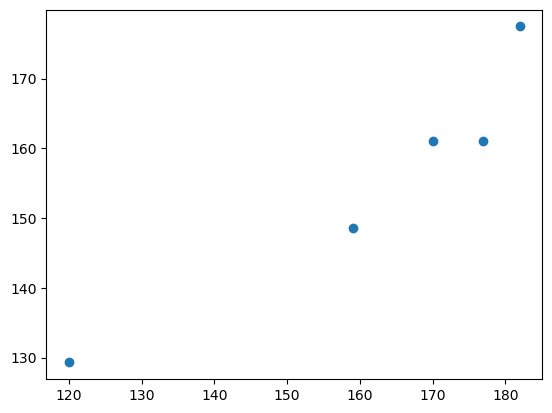

In [ ]:
## Assumptions
## plot a scatter plot for the prediction
plt.scatter(y_test,y_pred_test)

In [ ]:
## Residuals
residuals=y_test-y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

/tmp/ipykernel_491/2747191050.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<AxesSubplot: xlabel='Height', ylabel='Density'>

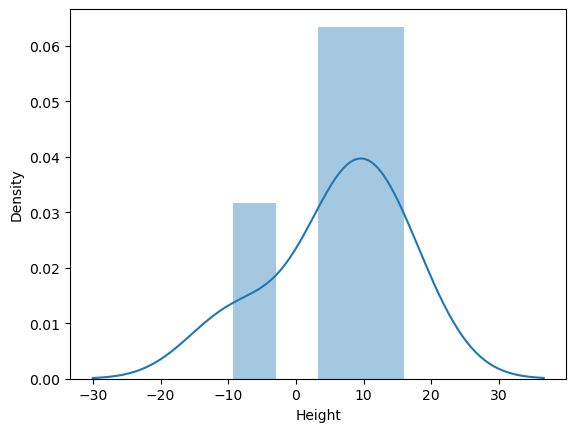

In [ ]:
## plot this residuals
import seaborn as sns
sns.distplot(residuals,kde=True)

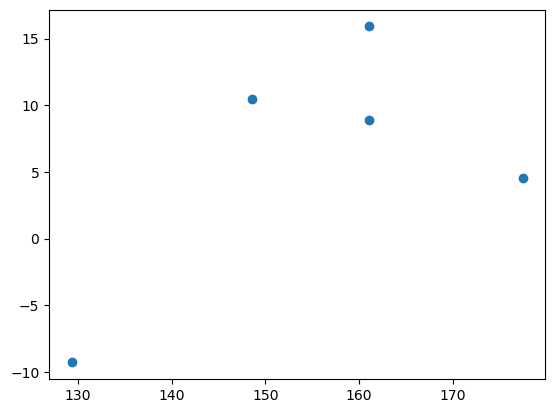

In [ ]:
## Scatter plot with respect to prediction and residuals
## uniform distribution
plt.scatter(y_pred_test,residuals)